In [1]:
import torch

torch.backends.quantized.engine = "qnnpack"

import numpy as np

# if torch.backends.mps.is_available():
#     DEVICE = torch.device("mps")
# elif torch.cuda.is_available():
#     DEVICE = torch.device("cuda")
# else:
#     DEVICE = torch.device("cpu")
DEVICE = torch.device("cpu")

torch.manual_seed(42)
np.random.seed(42)
print("Device:", DEVICE)

Device: cpu


In [2]:
import os


def read_ply_xyz(path):
    pts = []
    in_data = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line == "end_header":
                in_data = True
                continue
            if in_data and line:
                parts = line.split()
                pts.append([float(parts[0]), float(parts[1]), float(parts[2])])
    return torch.tensor(pts, dtype=torch.float32)


_ply_path = "../data/OmniObject3D/points/chair/chair_001/pcd_4096.ply"
if os.path.exists(_ply_path):
    _pts = read_ply_xyz(_ply_path)
    print(
        f"PLY loaded: {tuple(_pts.shape)}  min={_pts.min(0).values.tolist()}  max={_pts.max(0).values.tolist()}"
    )

PLY loaded: (4096, 3)  min=[-200.94766235351562, -407.8655090332031, -247.7242431640625]  max=[258.3512878417969, 365.4542541503906, 249.87327575683594]


### Point cloud normalisation

Raw PLY coordinates are in millimetres and are not centred.  We centre and
scale to fit inside the unit sphere (radius 1) so they align with the
normalised mesh templates used in the GCN stages later.

In [3]:
def normalise_points(pts):
    centre = (pts.max(0).values + pts.min(0).values) / 2.0
    pts = pts - centre
    scale = pts.norm(dim=-1).max().clamp(min=1e-8)
    return pts / scale

### Camera utilities

OmniObject3D stores camera poses as 4×4 **camera-to-world** matrices (same
convention as NeRF / instant-ngp).  The `focal` value is derived from the
`camera_angle_x` field:

  focal_px = W / (2 * tan(camera_angle_x / 2))
  focal_norm = focal_px / (W / 2) = 1 / tan(camera_angle_x / 2)

We store the *world-to-camera* rotation R and translation T so that
the existing `project_vertices` helper (from pix2mesh_dinov2.py) works
without modification:

  v_cam = R @ v_world + T

In [4]:
def c2w_to_Rt(c2w):
    R_c2w = c2w[:3, :3]
    t_cam = c2w[:3, 3]
    R = R_c2w.T
    T = -R @ t_cam
    return R, T


def focal_from_angle(camera_angle_x):
    return 1.0 / float(np.tan(camera_angle_x / 2.0))

In [8]:
import json
import random
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

DINO_MEAN = [0.485, 0.456, 0.406]
DINO_STD = [0.229, 0.224, 0.225]

OMNI_CATEGORIES = ["chair", "sofa"]


class OmniObject3DDataset(Dataset):
    def __init__(
        self,
        root: str,
        split: str = "train",
        categories: list = None,
        img_size: int = 224,
        n_pts: int = 4096,
        random_view: bool = True,
    ):
        super().__init__()
        self.root = Path(root)
        self.n_pts = n_pts
        self.random_view = random_view
        self.img_tfm = transforms.Compose(
            [
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(DINO_MEAN, DINO_STD),
            ]
        )

        cats = categories or OMNI_CATEGORIES
        self.samples = self._collect_instances(cats, split)
        print(
            f"OmniObject3DDataset [{split}]: {len(self.samples)} instances "
            f"from {cats}"
        )

    def _collect_instances(self, cats, split):
        all_instances = []
        for cat in cats:
            cat_raw_dir = self.root / "raw" / cat
            if not cat_raw_dir.exists():
                continue

            for obj_dir in sorted(cat_raw_dir.iterdir()):
                obj_id = obj_dir.name
                tf_path = obj_dir / "transforms.json"
                pcd_path = self.root / "points" / cat / obj_id / "pcd_4096.ply"
                if tf_path.exists() and pcd_path.exists():
                    all_instances.append((cat, obj_id))

        random.seed(42)
        random.shuffle(all_instances)
        n = len(all_instances)
        cut_val = int(0.8 * n)
        cut_test = int(0.9 * n)
        splits = {
            "train": all_instances[:cut_val],
            "val": all_instances[cut_val:cut_test],
            "test": all_instances[cut_test:],
        }

        return splits[split]

    def _load_transforms(self, cat: str, obj_id: str):
        tf_path = self.root / "raw" / cat / obj_id / "transforms.json"
        with open(tf_path) as fh:
            meta = json.load(fh)
        focal = focal_from_angle(meta["camera_angle_x"])
        frames = meta["frames"]  # list of {file_path, transform_matrix}
        return frames, focal

    def _load_image(self, cat: str, obj_id: str, filename: str):
        img_path = self.root / "raw" / cat / obj_id / filename
        img = Image.open(img_path).convert("RGB")
        return self.img_tfm(img)

    def _load_points(self, cat: str, obj_id: str):
        pcd_path = self.root / "points" / cat / obj_id / "pcd_4096.ply"
        pts = read_ply_xyz(str(pcd_path))  # [4096, 3]
        pts = normalise_points(pts)  # → unit sphere
        if self.n_pts < pts.shape[0]:
            idx = torch.randperm(pts.shape[0])[: self.n_pts]
            pts = pts[idx]
        return pts  # [n_pts, 3]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cat, obj_id = self.samples[idx]

        # 1. Load camera metadata
        frames, focal = self._load_transforms(cat, obj_id)

        # 2. Pick one view
        view_idx = random.randrange(len(frames)) if self.random_view else 0
        frame = frames[view_idx]

        # 3. Load image
        image = self._load_image(cat, obj_id, frame["file_path"])

        # 4. Parse c2w → R, T (world-to-camera)
        c2w = torch.tensor(frame["transform_matrix"], dtype=torch.float32)  # [4,4]
        R, T = c2w_to_Rt(c2w)

        # 5. Load point cloud
        gt_pts = self._load_points(cat, obj_id)

        return {
            "image": image,  # [3, H, W]
            "gt_points": gt_pts,  # [n_pts, 3]
            "rot": R,  # [3, 3]
            "trans": T,  # [3]
            "focal": torch.tensor(focal, dtype=torch.float32),  # scalar
            "category": cat,
            "instance": obj_id,
            "view_idx": view_idx,
        }


OMNI_ROOT = "../data/OmniObject3D"

train_ds = OmniObject3DDataset(OMNI_ROOT, split="train", categories=["chair", "sofa"])
val_ds = OmniObject3DDataset(OMNI_ROOT, split="val", categories=["chair", "sofa"])
test_ds = OmniObject3DDataset(OMNI_ROOT, split="test", categories=["chair", "sofa"])

print(
    f"\nSplit sizes — train: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)}"
)

OmniObject3DDataset [train]: 34 instances from ['chair', 'sofa']
OmniObject3DDataset [val]: 4 instances from ['chair', 'sofa']
OmniObject3DDataset [test]: 5 instances from ['chair', 'sofa']

Split sizes — train: 34  val: 4  test: 5


In [9]:
sample = train_ds[0]
print("\nSample keys and shapes:")
for k, v in sample.items():
    if hasattr(v, "shape"):
        print(f"  {k:12s}: {tuple(v.shape)}  dtype={v.dtype}")
    else:
        print(f"  {k:12s}: {v!r}")


Sample keys and shapes:
  image       : (3, 224, 224)  dtype=torch.float32
  gt_points   : (4096, 3)  dtype=torch.float32
  rot         : (3, 3)  dtype=torch.float32
  trans       : (3,)  dtype=torch.float32
  focal       : ()  dtype=torch.float32
  category    : 'chair'
  instance    : 'chair_010'
  view_idx    : 11


In [10]:
# Verify R is a proper rotation matrix (R^T R ≈ I, det ≈ +1)
R = sample["rot"]
print(f"\nRotation sanity:")
print(f"  R^T R ≈ I  residual: {(R.T @ R - torch.eye(3)).abs().max().item():.2e}")
print(f"  det(R)             : {torch.linalg.det(R).item():.6f}")


Rotation sanity:
  R^T R ≈ I  residual: 2.38e-07
  det(R)             : 1.000000


In [11]:
# Verify point cloud normalisation
pts = sample["gt_points"]
print(f"\nPoint cloud sanity:")
print(f"  shape : {tuple(pts.shape)}")
print(f"  centre: {pts.mean(0).tolist()}")
print(f"  radius: {pts.norm(dim=-1).max().item():.4f}  (should be ≤ 1.0)")


Point cloud sanity:
  shape : (4096, 3)
  centre: [-0.07225415855646133, -0.05177357792854309, -0.0003347770543769002]
  radius: 1.0000  (should be ≤ 1.0)


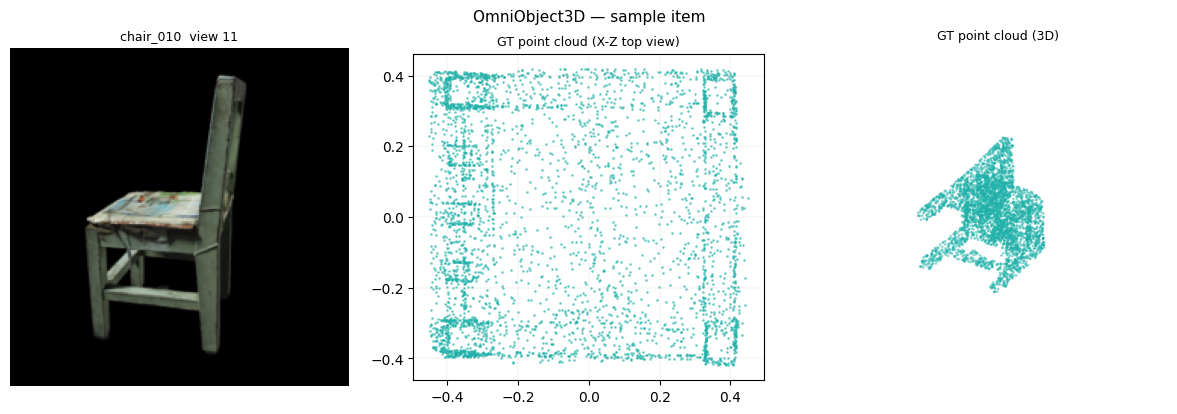

In [13]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 4))

# ── input image ───────────────────────────────────────────────────────────────
ax_img = fig.add_subplot(1, 3, 1)
mean = torch.tensor(DINO_MEAN).view(3, 1, 1)
std = torch.tensor(DINO_STD).view(3, 1, 1)
img_vis = (sample["image"] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
ax_img.imshow(img_vis)
ax_img.set_title(f"{sample['instance']}  view {sample['view_idx']}", fontsize=9)
ax_img.axis("off")

# ── GT point cloud (top view) ─────────────────────────────────────────────────
ax_top = fig.add_subplot(1, 3, 2)
pts_np = sample["gt_points"].numpy()
ax_top.scatter(pts_np[:, 0], pts_np[:, 2], s=1, c="#20B2AA", alpha=0.5)
ax_top.set_title("GT point cloud (X-Z top view)", fontsize=9)
ax_top.set_aspect("equal")
ax_top.grid(True, linewidth=0.3, alpha=0.4)

# ── GT point cloud (3D) ───────────────────────────────────────────────────────
ax_3d = fig.add_subplot(1, 3, 3, projection="3d")
ax_3d.scatter(*pts_np.T, s=1, c="#20B2AA", alpha=0.4)
ax_3d.set_title("GT point cloud (3D)", fontsize=9)
ax_3d.set_axis_off()
lim = 1.0
ax_3d.set_xlim(-lim, lim)
ax_3d.set_ylim(-lim, lim)
ax_3d.set_zlim(-lim, lim)

plt.suptitle("OmniObject3D — sample item", fontsize=11)
plt.tight_layout()
plt.show()

In [14]:
from torch.utils.data import DataLoader


def collate_omni(batch):
    """Default collate works for all tensor fields; strings need a list."""
    keys_tensor = ["image", "gt_points", "rot", "trans", "focal"]
    keys_str = ["category", "instance", "view_idx"]
    out = {k: torch.stack([b[k] for b in batch]) for k in keys_tensor}
    out.update({k: [b[k] for b in batch] for k in keys_str})
    return out


train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_omni,
)
val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_omni,
)

batch = next(iter(train_loader))
print("Batch shapes:")
for k, v in batch.items():
    if hasattr(v, "shape"):
        print(f"  {k:12s}: {tuple(v.shape)}")
    else:
        print(f"  {k:12s}: {v}")

Batch shapes:
  image       : (8, 3, 224, 224)
  gt_points   : (8, 4096, 3)
  rot         : (8, 3, 3)
  trans       : (8, 3)
  focal       : (8,)
  category    : ['chair', 'chair', 'chair', 'chair', 'chair', 'sofa', 'sofa', 'chair']
  instance    : ['chair_028', 'chair_011', 'chair_020', 'chair_026', 'chair_023', 'sofa_001', 'sofa_004', 'chair_005']
  view_idx    : [11, 19, 8, 1, 23, 14, 17, 3]


In [15]:
from collections import Counter

all_ds = OmniObject3DDataset(OMNI_ROOT, split="train", categories=["chair", "sofa"])

cat_counts = Counter(cat for cat, _ in all_ds.samples)
print("\nInstance counts per category (train split):")
for cat, count in sorted(cat_counts.items()):
    print(f"  {cat:10s}: {count}")

OmniObject3DDataset [train]: 34 instances from ['chair', 'sofa']

Instance counts per category (train split):
  chair     : 22
  sofa      : 12
